# Clustering of RNA Structures

This notebook provides a starting point for the different tasks involved in clustering RNA secondary structures.

## Tasks covered
1. **Data loading** – load RNA sequences and secondary structures
2. **Feature extraction** – convert dot-bracket notation into numerical feature vectors
3. **Pairwise distance computation** – compare structures using edit distance and base-pair distance
4. **Clustering** – apply K-means and hierarchical (agglomerative) clustering
5. **Evaluation** – measure cluster quality with silhouette score and dendrogram
6. **Visualisation** – PCA projection and heatmap of the distance matrix

## 1. Imports and setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import RNA
import time

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection

from sklearn.manifold import MDS


%matplotlib inline
sns.set_theme(style="whitegrid")

#### necessary shenaningans to use sklearn_extras with python > 3.12

In [2]:
import sys

# Create a fake distutils module to satisfy the import
try:
    import distutils.version
except ImportError:
    import packaging.version
    import types
    
    # Create a dummy module
    distutils = types.ModuleType("distutils")
    distutils.version = types.ModuleType("distutils.version")
    distutils.version.LooseVersion = packaging.version.Version
    sys.modules["distutils"] = distutils
    sys.modules["distutils.version"] = distutils.version

from sklearn_extra.cluster import KMedoids  # This should work now


from sklearn_extra.cluster import KMedoids


## 2. Data loading

RNA secondary structures are commonly stored in **dot-bracket** notation alongside the nucleotide sequence.
Replace the sample data below with your own dataset (e.g. from a FASTA/Stockholm file or a database query).

In [3]:
sequence = "GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGGUCCUGUGUUCGAUCCACAGAAUUCGCACCA"

In [4]:
rna_sequences = [
    # tRNA-Phe (levure S. cerevisiae) — structure en feuille de trèfle classique
    # Source: RCSB PDB 1EHZ
    ("tRNA_Phe", "GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGGUCCUGUGUUCGAUCCACAGAAUUCGCACCA"),

    # 5S rRNA (E. coli) — hélices multiples, structure compacte
    # Source: RFAM RF00001, accession J01695
    ("5S_rRNA", "UGCCUGGCGGCCGUAGCGCGGUGGUCCCACCUGACCCCAUGCCGAACUCAGAAGUGAAACGCCGUAGCGCCGAUGGUAGUGUGGGGUCUCCCCAUGCGAGAGUAGGUCAGGC"),

    # Hammerhead ribozyme (Schistosoma mansoni) — motif catalytique
    # Source: RFAM RF00008
    ("Hammerhead_ribozyme", "AACUGAUGAGUCCGUGAGGACGAAACAGC"),

    # U1 snRNA (humain) — impliquée dans l'épissage
    # Source: RFAM RF00003, accession X59350
    ("U1_snRNA", "AUACUUACCUGGCAGGGGAGAUACCAUGAUUUGCGUAAGUCUCUUCAGUGCAUUGCAGGUGUAGUGCUCCUGGGCAAGUCCCCAAAGGAGCUAAUUUCCAUGGGGCUAAGUGAGAAUAUCAAAGCUAGUUUCUCCAAGGUGCAGUCAGAGCUGCUUCGCACUUUCGGUGUCUGCUCUUCGCAGCUUCGCAGCUUCGGUCUUCUGCAUGGGAGAGCUCUGCAAAAGCGAAGCGGUGCAGAGCAGAGUCCCGGUCUGGAAGUGAGAAUAUCUCAAAGCUAGUUUCUCCGAGGUGCAGUCAGAGCUGCUUCGCACUUUCGGUGUCUGCUCUUCGCAGCUUCGCAGCUUCGGUCUUCUGCAUGGGAGAGCUCUGCAAAAGCGAAGCGGUGCAGAGCAGAGUCCCGGUCUGGAAGUGAGAAUAUCUCAAAGCUAGUUUCUCCAAGGUGCAGUCAGAGCUGCUUCGCACUUUCGGUGUCUGCUCUUCGCAG"),

    # Purine riboswitch aptamer (Bacillus subtilis) — change de conformation selon ligand
    # Source: RFAM RF00167, accession AY330909
    ("Purine_riboswitch", "UUAUAUAACUCAUAUCAAUAUGGUCUAAAAUAAUGCGCUAACAGUGUAGAUGAAAACAUAGCCCUAGGUGCUGUCGAGCUUUCGCAGCUUCGGCUUACAGGCAUAUGGGCAUCAAGCUAUUUAGCCGAGAUUAAAGAGAUUCGCUGUUGAAAUGUCGAAGACAGCGCAGCUUCGGCUU"),

    # Iron response element (IRE) — courte tige-boucle régulatrice
    # Source: RFAM RF00037
    ("IRE", "CUUCCUUCAGUGCUUCGGAAGG"),
]

### 2a. Self coded Partitioning

In [5]:
def calculate_partition_function(unpaired_probs, paired_probs, beta, m=3):
    """
    Computes the partition function Z[i,j] for an RNA alignment.
    Based on the recursion: Z[i,j] = Z[i,j-1]*exp(beta*UNP(j)) + sum(...)
    """
    n = len(unpaired_probs)
    # Z matrix including an extra index for Z[i, i-1] = 1.0 cases
    Z = np.zeros((n + 1, n + 1), dtype=np.float64)
    
    # Initialization
    for i in range(n):
        Z[i, i] = np.exp(beta * unpaired_probs[i])
        Z[i, i-1] = 1.0
    if n > 0: Z[n, n-1] = 1.0

    # DP Recursion
    for length in range(1, n):
        for i in range(n - length):
            j = i + length
            
            # Case 1: j is unpaired
            # Z[i, j] = Z[i, j-1] * exp(beta * UNP(j))
            z_val = Z[i, j-1] * np.exp(beta * unpaired_probs[j])
            
            # Case 2: j is paired with some k
            # sum over k: Z[i, k-1] * exp(beta * PAIR(k,j)) * Z[k+1, j-1]
            for k in range(i, j - m):
                # Handle the k=i case where Z[i, k-1] is Z[i, i-1] = 1.0
                term_left = Z[i, k-1] if k > i else 1.0
                z_val += term_left * np.exp(beta * paired_probs[k, j]) * Z[k+1, j-1]
                
            Z[i, j] = z_val
            
    return Z

def stochastic_traceback(i, j, Z, unpaired_probs, paired_probs, beta, structure, m=3):
    """
    Produces a random substructure for indices i..j based on partition function Z.
    """
    if j < i:
        return

    # Select a random float for selecting the case
    x = np.random.uniform(0, Z[i, j])
    
    # Check Case: j is unpaired [cite: 306]
    z_unpaired = (Z[i, j-1] if j > i else 1.0) * np.exp(beta * unpaired_probs[j])
    
    if x < z_unpaired:
        stochastic_traceback(i, j-1, Z, unpaired_probs, paired_probs, beta, structure, m)
        return

    # Check Case: j is paired with k [cite: 309]
    cumulative_z = z_unpaired
    for k in range(i, j - m):
        term_left = Z[i, k-1] if k > i else 1.0
        z_paired = term_left * np.exp(beta * paired_probs[k, j]) * Z[k+1, j-1]
        cumulative_z += z_paired
        
        if x < cumulative_z:
            structure[k] = "("
            structure[j] = ")"
            # Recursively sample the two independent sub-problems
            stochastic_traceback(i, k-1, Z, unpaired_probs, paired_probs, beta, structure, m)
            stochastic_traceback(k+1, j-1, Z, unpaired_probs, paired_probs, beta, structure, m)
            return

def sample_structures(unpaired_probs, paired_probs, beta, num_samples=1000, m=3):
    """Generates a list of sampled RnaMolecule structures."""
    n = len(unpaired_probs)
    Z = calculate_partition_function(unpaired_probs, paired_probs, beta, m)
    
    samples = []
    for _ in range(num_samples):
        struct_list = ["."] * n
        stochastic_traceback(0, n - 1, Z, unpaired_probs, paired_probs, beta, struct_list, m)
        samples.append("".join(struct_list))
    return samples

In [6]:
def db2pairs(dbstring):
    base_pairs = []
    stack = []
    
    for index, char in enumerate(dbstring):
        position = index + 1  
        
        if char == '(':
            stack.append(position)
        elif char == ')':
            if not stack:
                raise ValueError(f"Error at position {position} : No matching opening parenthesis")
            opening_pos = stack.pop()
            base_pairs.append((opening_pos, position))
        elif char == '.':
            continue
        else:
            raise ValueError(f"Incompatible character '{char}' detected at the {position}.")
            
    if stack:
        raise ValueError(f"Error : {len(stack)} No closed parenthesis (positions : {stack}).")
        
    return sorted(base_pairs)

def probability_matrix(samples):
    """Estimates base pair probabilities from samples."""
    n = len(samples[0])
    prob_matrix = np.zeros((n, n))
    
    for s in samples:
        pairs = db2pairs(s) 
        for i, j in pairs:
            prob_matrix[i-1, j-1] += 1
            
    prob_matrix /= len(samples)
    return prob_matrix

### 2b. McCaskill algorithm using the ViennaRNA package

In [7]:
md = RNA.md()
md.uniq_ML = 1  

fc = RNA.fold_compound(sequence, md)

# McCaskill algorithm 
(propensity, ensemble_energy) = fc.pf()

# Base-pairing probability matrix 
bpp_matrix = fc.bpp()

print(f"Ensemble Free Energy: {ensemble_energy:.2f} kcal/mol")
print(f"Probability of base 1 pairing with base 20: {bpp_matrix[1][20]:.4f}")
print("Propensity", propensity)
print("bpp", bpp_matrix)

Ensemble Free Energy: -24.13 kcal/mol
Probability of base 1 pairing with base 20: 0.0000
Propensity (((((({...,(({{{{,({.,,,,.||,||}}},.,.||||..||||,,{{{...,,}}}}))))))))))....
bpp ((0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.4688633485105237e-08, 1.4548592975111988e-08, 6.224807594742447e-08, 0.0, 0.0, 0.0004176119762543964, 3.543360502342885e-09, 2.7470182089435517e-07, 0.0, 0.0, 6.285470146294349e-07, 1.5581073355295388e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.1484891337999578e-06, 0.0, 1.6683725855881282e-06, 2.3750150611037378e-08, 0.0, 0.0, 0.0, 1.2257676984854295e-07, 1.1704616101891353e-08, 0.0, 0.0, 0.0, 0.

In [8]:
def boltzmann_sampling(fold_compound):
    """ 
    return a backtracked structure from a fold_compound where the partition function is already computed
    """ 
    return fold_compound.pbacktrack()

print(boltzmann_sampling(fc))

def sampling_structures(fold_compound, num_samples=1000):
    """Generates a dataframe of sampled RnaMolecule structures."""
    samples = []
    for _ in range(num_samples):
        struct = boltzmann_sampling(fold_compound)
        struct_energy = fold_compound.eval_structure(struct)
        samples.append((struct, struct_energy))
       

    df_samples = pd.DataFrame(samples, columns=["structure", "structure_energy"])
    return df_samples

# Generate 1000 samples as a dataframe
df_samples = sampling_structures(fc, num_samples=1000)
print(df_samples.head())

((((((((........(((((((((((..((((...........))))..))))))..))).))))))))))....
                                           structure  structure_energy
0  ((((((((......(.((((.((((((..((((...........))...        -21.100000
1  ((((((.....((.(.((((.((((((..((((...........))...        -21.200001
2  (((((((..((((........)))).(((((.(....))))))......        -21.500000
3  (((((((..((((........)))).((((((....).)))))......        -22.100000
4  ((((((.....((((((.((......)).))))))...((((..((...        -22.100000


### Comparison of the two matrices

Match of our results of partitioning between bpp matrix and the self coded partitioning matrix.

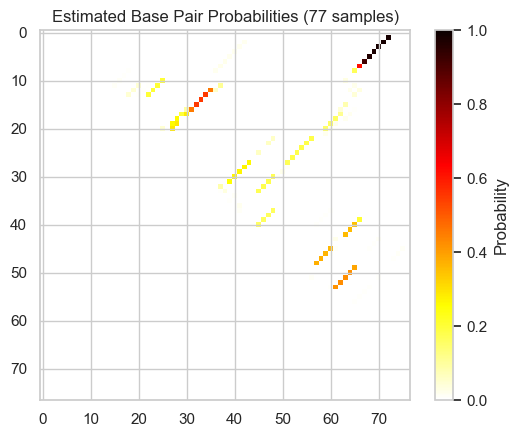

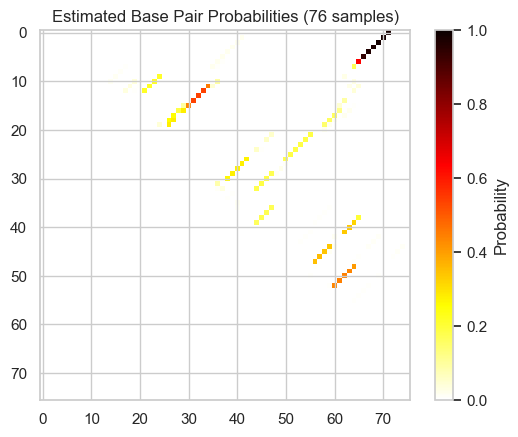

In [9]:
def plot_probability_heatmap(matrix):
    """Visualizes heatmap of base pair probabilities."""
    plt.imshow(matrix, cmap='hot_r', vmin=0, vmax=1)
    plt.title(f"Estimated Base Pair Probabilities ({len(matrix)} samples)")
    plt.colorbar(label="Probability")
    plt.show()

matrix = probability_matrix(df_samples["structure"].tolist())
plot_probability_heatmap(bpp_matrix)
plot_probability_heatmap(matrix)

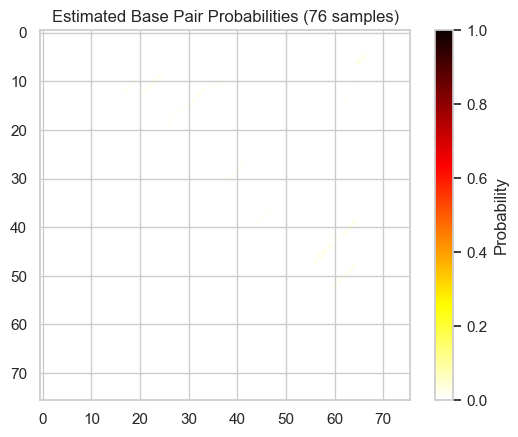

In [10]:
# Mettre la bpp_matric sous forme de matrice de probabilité
bpp_matrix = np.array(bpp_matrix)
#Enlever la première ligne et la première colonne de bpp_matrix pour correspondre à l'indexation 0-based de matrix
reshaped_bpp = bpp_matrix[1:, 1:]
difference_matrix = np.abs(reshaped_bpp-matrix)
plot_probability_heatmap(difference_matrix)

Dot-plot from pre-generated samples

In [11]:
def parse_RNA_structure(dbstring):
    base_pairs = []
    stack = []
    
    for index, char in enumerate(dbstring):
        position = index + 1  
        
        if char == '(':
            stack.append(position)
        elif char == ')':
            if not stack:
                raise ValueError(f"Error at position {position} : No matching opening parenthesis")
            opening_pos = stack.pop()
            base_pairs.append((opening_pos, position))
        elif char == '.':
            continue
        else:
            raise ValueError(f"Incompatible character '{char}' detected at the {position}.")
            
    if stack:
        raise ValueError(f"Error : {len(stack)} No closed parenthesis (positions : {stack}).")
        
    return sorted(base_pairs)

def plot_dot_plot(samples, sequence_name="RNA Sequence"):
    """
    Visualizes base pair probabilities using imshow to create a Dot Plot.
    
    Args:
        samples (list): List of dot-bracket strings from stochastic sampling.
        sequence_name (str): Name of the sequence for the plot title.
    """
    n = len(samples[0])
    # Initialize a matrix to store pair frequencies
    prob_matrix = np.zeros((n, n))
    
    # 1. Count base pair occurrences in samples
    for structure in samples:
        # Use your existing parse function to get pairs
        pairs = parse_RNA_structure(structure)
        for i, j in pairs:
            # Convert 1-based indexing from parse_RNA_structure to 0-based for numpy
            prob_matrix[i-1, j-1] += 1
            # Dot plots are often symmetric
            prob_matrix[j-1, i-1] += 1
            
    # 2. Normalize to get probabilities (0.0 to 1.0)
    prob_matrix /= len(samples)
    
    # 3. Create the plot using imshow
    plt.figure(figsize=(8, 8))
    # 'hot_r' (reversed hot) shows high probability as dark/red and low as white
    plt.imshow(prob_matrix, cmap='hot_r', interpolation='nearest')
    
    plt.title(f"Dot Plot: Base Pair Probabilities ({sequence_name})\nEstimated from {len(samples)} samples")
    plt.xlabel("Sequence Position")
    plt.ylabel("Sequence Position")
    plt.colorbar(label="Probability")

    plt.show()


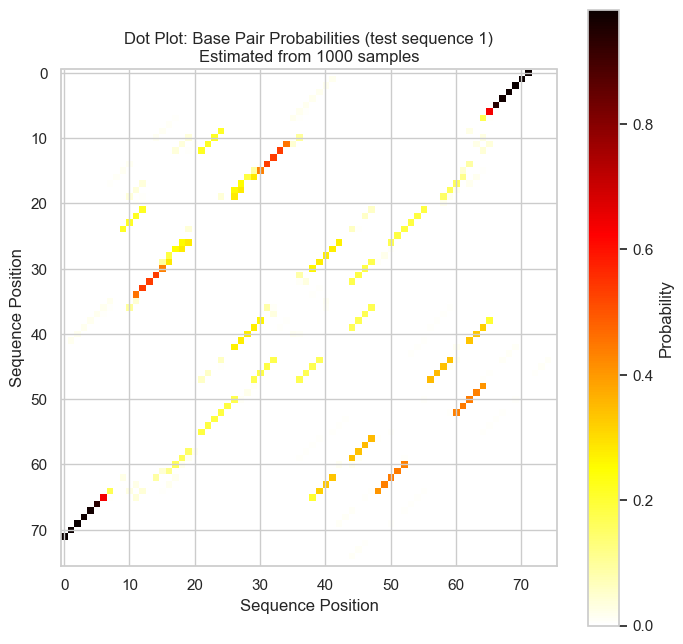

In [12]:
plot_dot_plot(samples=df_samples["structure"].tolist(), sequence_name="test sequence 1")

## 3. Feature extraction

We encode each dot-bracket string as a numeric vector:
- `(` → 1
- `)` → -1
- `.` → 0

Sequences of different lengths are zero-padded to the maximum length.

In [13]:
ENCODING = {"(": 1, ")": -1, ".": 0}

def encode_structure(struct: str, max_len: int) -> np.ndarray:
    """Encode a dot-bracket string to a zero-padded numeric array."""
    vec = [ENCODING.get(c, 0) for c in struct]
    vec += [0] * (max_len - len(vec))  # zero-pad
    return np.array(vec, dtype=float)

max_len = df_samples["structure"].str.len().max()
X = np.vstack([encode_structure(s, max_len) for s in df_samples["structure"]])

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (1000, 76)


In [14]:
print("Matrix", X)
print("Length", max_len)

Matrix [[1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 ...
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]]
Length 76


## 4. Pairwise distance computation

Two common distances for RNA structures:
- **Hamming Distance** 
- **Levenshtein distance** on the encoded vectors (proxy)
- **Edit distance** (string edit / Levenshtein) on the raw dot-bracket strings

### 4a. Levenshtein distance

In [16]:
# --- String edit distance (Levenshtein) ---
def edit_distance(s1: str, s2: str) -> int:
    """Compute the Levenshtein edit distance between two strings."""
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev = dp[:]
        dp[0] = i
        for j in range(1, n + 1):
            if s1[i - 1] == s2[j - 1]:
                dp[j] = prev[j - 1]
            else:
                dp[j] = 1 + min(prev[j], dp[j - 1], prev[j - 1])
    return dp[n]

# structs = df_samples["structure"].tolist()
# n = len(structs)
# dist_Levenshtein = np.zeros((n, n))
# for i in range(n):
#     for j in range(i + 1, n):
#         d = edit_distance(structs[i], structs[j])
#         dist_Levenshtein[i, j] = d
#         dist_Levenshtein[j, i] = d

# print("\nEdit distance matrix:")
# print(dist_Levenshtein)

### 4b. Hamming distance

In [17]:
def distance_hamming(str1, str2):
    """
    compute the hamming distance between two strings of equal length
    """
    assert(len(str1) == len(str2))
    return sum([str1[i] != str2[i] for i in range(len(str1))])

samples = df_samples["structure"].tolist()
N = len(samples)

hamming_distance_matrix = np.array([[distance_hamming(samples[i], samples[j]) for i in range(N)] for j in range(N)])
print("\nHamming distance matrix:")
print(hamming_distance_matrix)


Hamming distance matrix:
[[ 0  4 39 ... 39 40 41]
 [ 4  0 37 ... 37 38 37]
 [39 37  0 ...  2 42  6]
 ...
 [39 37  2 ...  0 41  4]
 [40 38 42 ... 41  0 42]
 [41 37  6 ...  4 42  0]]


### 4c. Base pair distance via ViennaRNA

In [18]:
def distance_bp(structs):
    n = len(structs)
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = RNA.bp_distance(structs[i], structs[j])
            dist[i, j] = d
            dist[j, i] = d
    return dist

structs = df_samples["structure"].tolist()
dist_bp = distance_bp(structs)

print(f"Shape: {dist_bp.shape}")
print(f"Max distance: {dist_bp.max():.0f}")

Shape: (1000, 1000)
Max distance: 51


### 4c. Convergence analysis

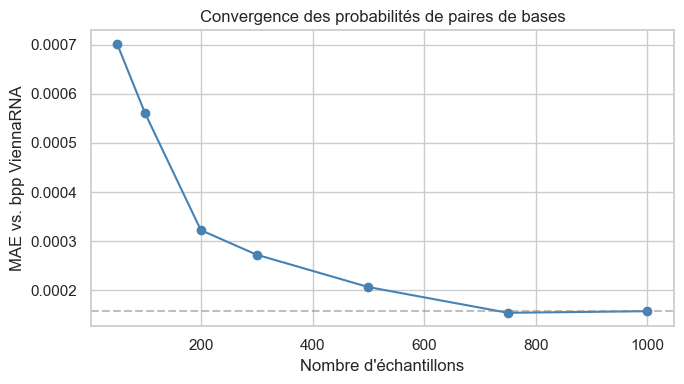

In [19]:
sample_sizes = [50, 100, 200, 300, 500, 750, 1000]
all_structs = df_samples["structure"].tolist()

# Matrice de référence = ViennaRNA bpp (vérité terrain)
bpp_ref = np.array(fc.bpp())[1:, 1:]

errors = []
for n in sample_sizes:
    subset = all_structs[:n]
    emp_matrix = probability_matrix(subset)
    # Erreur = MAE entre matrice empirique et référence ViennaRNA
    mae = np.mean(np.abs(emp_matrix - bpp_ref))
    errors.append(mae)

plt.figure(figsize=(7, 4))
plt.plot(sample_sizes, errors, marker="o", color="steelblue")
plt.xlabel("Nombre d'échantillons")
plt.ylabel("MAE vs. bpp ViennaRNA")
plt.title("Convergence des probabilités de paires de bases")
plt.axhline(errors[-1], linestyle="--", color="gray", alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Clustering

### 5a. K-means clustering by Kmedoids

In [20]:
print(f"Structures uniques : {df_samples['structure'].nunique()}")
print(df_samples['structure'].value_counts().head(5))
print(f"Séquence utilisée : {sequence}")

Structures uniques : 381
structure
(((((((..((((........)))).(((((.......))))).....(((((.......))))))))))))....    65
(((((((....((((((.((......)).)))))).((((....))))(((((.......))))))))))))....    47
(((((((..((((........)))).((((((....).))))).....(((((.......))))))))))))....    44
((((((.....((((((.((......)).))))))...((((..((((........))))..))))))))))....    34
((((((.....((((((((.......))).)))))...((((..((((........))))..))))))))))....    23
Name: count, dtype: int64
Séquence utilisée : GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGGUCCUGUGUUCGAUCCACAGAAUUCGCACCA


In [21]:
kmedoids = KMedoids(n_clusters=3, metric='precomputed', random_state=42, init='k-medoids++')
clusters = kmedoids.fit(hamming_distance_matrix)

labels = kmedoids.labels_
medoid_indices = kmedoids.medoid_indices_

df_samples["cluster_hamming"] = labels #adding the labels to the dataframe

print(f"Cluster Assignments: {labels}")
print(f"Medoid Indices (The 'Centers'): {medoid_indices}")
print(f"Representative RNA for Cluster 0: {samples[medoid_indices[0]]}")


Cluster Assignments: [2 2 1 1 0 0 0 0 2 0 0 2 0 1 0 0 1 2 1 0 0 0 1 0 1 0 0 0 2 1 0 0 1 1 0 1 1
 0 0 0 2 1 1 0 1 0 1 2 0 0 1 1 0 0 0 1 0 2 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0 2
 1 0 0 0 2 0 0 0 0 1 1 2 1 0 0 2 2 0 0 0 0 1 0 0 0 0 0 0 0 1 2 0 1 1 0 2 2
 0 1 2 0 0 1 2 1 2 2 0 1 2 0 0 0 0 2 0 0 1 1 0 0 0 2 1 2 0 1 2 0 0 1 0 0 0
 1 2 0 0 1 0 0 2 0 0 0 0 2 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 2 0 1 2 0 2 0 2 2
 0 0 1 1 2 0 0 0 1 1 2 0 1 0 1 2 0 0 0 0 0 0 0 0 0 0 2 2 2 0 0 0 0 2 0 1 0
 0 1 0 1 0 0 2 0 0 0 0 2 0 2 1 1 2 0 1 2 0 0 1 0 1 1 0 0 0 0 0 2 1 2 1 1 0
 2 1 0 1 0 0 0 0 1 2 0 2 1 0 1 1 1 1 0 1 2 1 0 0 1 0 0 1 2 1 0 0 0 0 0 1 0
 1 2 2 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 2 2 0 0 2 2 0 0 0 1 0 2 1 2 0 1 0
 1 0 1 0 1 2 0 0 0 1 0 1 1 2 1 1 0 1 1 1 0 0 1 0 0 1 0 0 0 1 0 2 0 2 1 2 0
 0 1 0 0 0 0 0 1 2 1 0 0 1 1 0 1 0 2 2 0 1 0 1 1 1 2 0 0 2 0 0 1 1 0 2 1 0
 2 2 1 0 0 0 2 1 0 1 0 0 1 0 0 0 0 0 0 1 1 0 2 1 0 0 0 0 0 1 2 1 1 1 0 0 2
 0 0 0 0 0 0 1 2 1 0 0 1 2 2 0 0 0 1 0 0 0 0 0 1 2 1 0 0 0 1 2 0 0 0 2 2 0
 0 0

c:\Etudes\X\3A\P2\CSC_52089\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


In [22]:
N_CLUSTERS = 6

kmed = KMedoids(n_clusters=N_CLUSTERS, metric="precomputed", init="heuristic", random_state=42)
df_samples["cluster_bp"] = kmed.fit_predict(dist_bp)


print(df_samples["cluster_bp"].value_counts())
print(f"Medoids (indices) : {kmed.medoid_indices_}")
print(f"Structures médoïdes :")
for i, idx in enumerate(kmed.medoid_indices_):
    print(f"  Cluster {i} : {df_samples['structure'].iloc[idx]}")

cluster_bp
0    462
2    166
4    151
1    112
3     82
5     27
Name: count, dtype: int64
Medoids (indices) : [ 18  12  81   7   4 208]
Structures médoïdes :
  Cluster 0 : (((((((..((((........)))).(((((.......))))).....(((((.......))))))))))))....
  Cluster 1 : (((((((....((((((.((......)).)))))).((((....))))(((((.......))))))))))))....
  Cluster 2 : ((((((.....((((((((.......))).)))))...((((..((((........))))..))))))))))....
  Cluster 3 : (((((((....((((((((.......))).))))).((((....))))(((((.......))))))))))))....
  Cluster 4 : ((((((.....((((((.((......)).))))))...((((..((((........))))..))))))))))....
  Cluster 5 : ((((((....(((((((.((......)).))))).)).((((..((((........))))..))))))))))....


c:\Etudes\X\3A\P2\CSC_52089\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Etudes\X\3A\P2\CSC_52089\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Etudes\X\3A\P2\CSC_52089\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


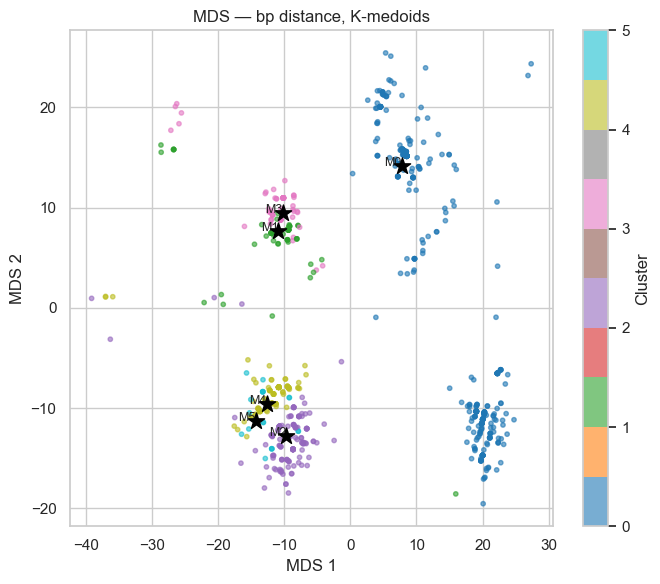

In [23]:
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_2d = mds.fit_transform(dist_bp)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=df_samples["cluster_bp"], cmap="tab10", s=10, alpha=0.6
)

for i, idx in enumerate(kmed.medoid_indices_):
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], s=150, marker="*",
                color="black", zorder=5)
    plt.annotate(f"M{i}", (X_2d[idx, 0], X_2d[idx, 1]),
                 fontsize=9, ha="right")

plt.colorbar(scatter, label="Cluster")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")
plt.title("MDS — bp distance, K-medoids")
plt.tight_layout()
plt.show()

%matplotlib inline

In [ ]:
scaled_sequences = MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=10).fit_transform(dist_hamming)

df_samples["hamming_MDS_2Dpos_x"] = scaled_sequences[:, 0]
df_samples["hamming_MDS_2Dpos_y"] = scaled_sequences[:, 1]

df_samples[[ "cluster_hamming", "hamming_MDS_2Dpos_x", "hamming_MDS_2Dpos_y"]]

NameError: name 'dist_hamming' is not defined

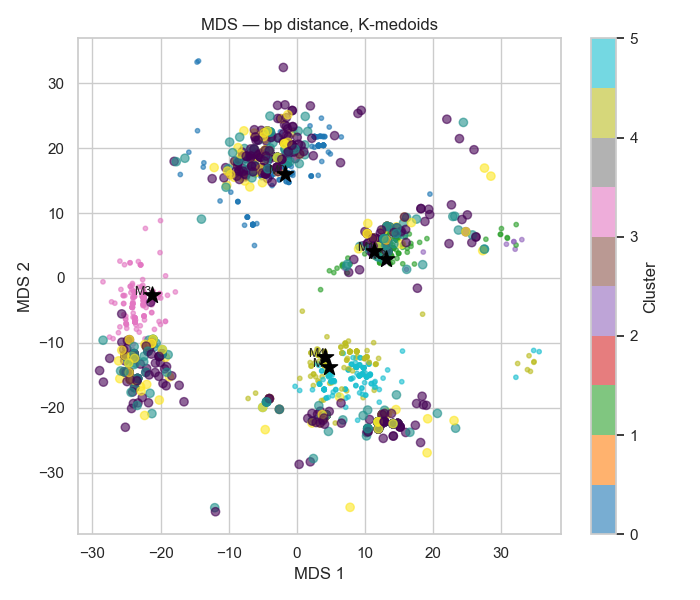

In [ ]:
plt.scatter(df_samples["hamming_MDS_2Dpos_x"], df_samples["hamming_MDS_2Dpos_y"], c=df_samples["cluster_hamming"], cmap='viridis', alpha=0.6)
plt.show()
%matplotlib inline

-22.399999618530273
-10.899999618530273


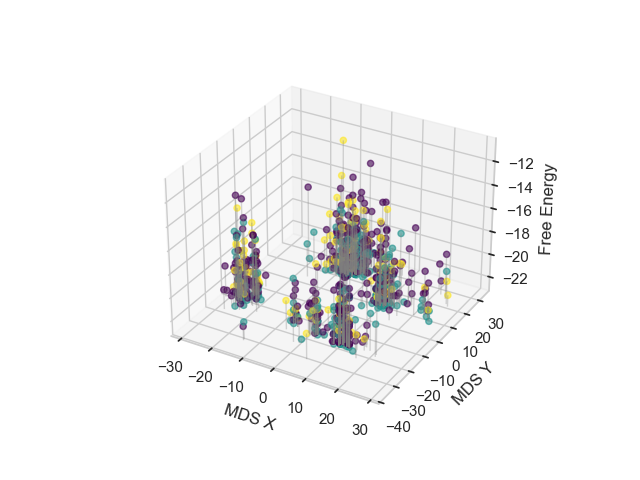

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

xs = df_samples["hamming_MDS_2Dpos_x"]
ys = df_samples["hamming_MDS_2Dpos_y"]
zs = df_samples["structure_energy"] 
ax.scatter(xs, ys, zs, c=df_samples["cluster_hamming"], cmap='viridis', alpha=0.6)

z_min = zs.min()
segments = [ [(x, y, z_min), (x, y, z)] for x, y, z in zip(xs, ys, zs)]

# Create the collection
line_col = Line3DCollection(segments, colors='gray', alpha=0.3, linewidths=1)
ax.add_collection3d(line_col)

ax.set_xlabel('MDS X')
ax.set_ylabel('MDS Y')
ax.set_zlabel('Free Energy')

print(z_min)
print(zs.max())

#pour avoir graphique D interactif. Si ça ne fonctionne pas, essayer !pip install ipympl puis relancer VSCode. Sinon retirer la ligne.
%matplotlib widget 


### 5b. Cluster probabilities

In [ ]:
cluster_probs = df_samples["cluster"].value_counts().sort_index() / len(df_samples)
print("Probabilités de cluster :")
print(cluster_probs.round(3))

bpp_total = probability_matrix(df_samples["structure"].tolist())

def cluster_bpp_matrix(df, cluster_id):
    structs_c = df[df["cluster"] == cluster_id]["structure"].tolist()
    return probability_matrix(structs_c)


Probabilités de cluster :
cluster
0    0.130
1    0.171
2    0.279
3    0.184
4    0.170
5    0.066
Name: count, dtype: float64


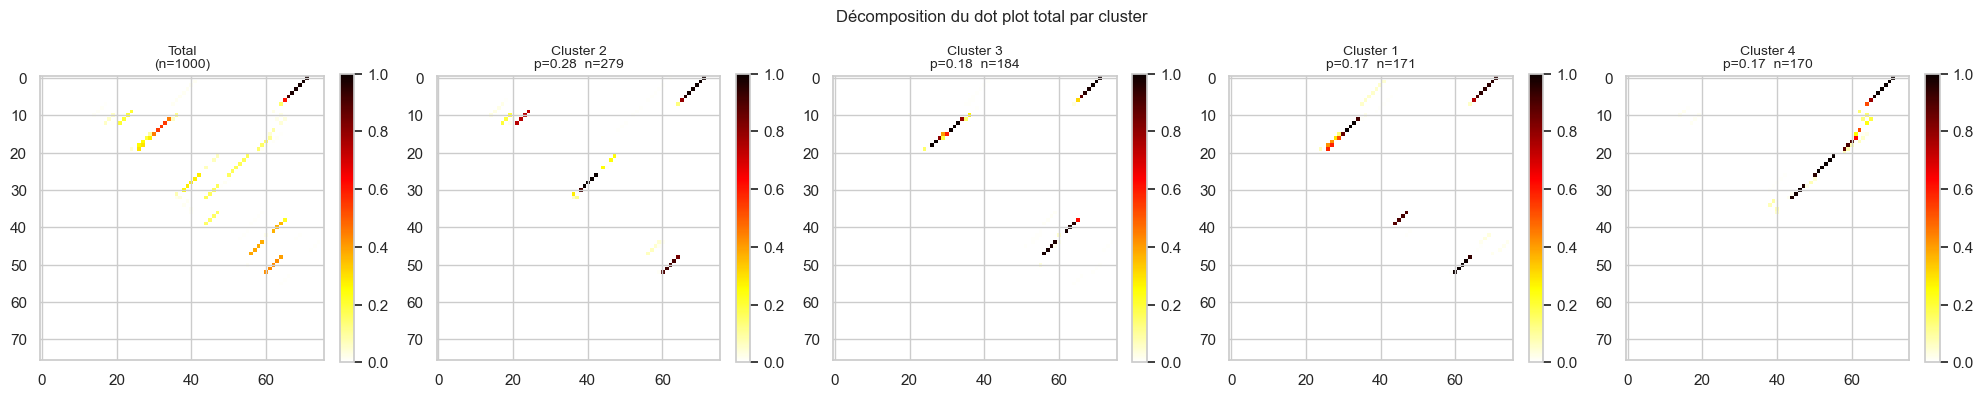

In [ ]:
top_clusters = cluster_probs.sort_values(ascending=False).index.tolist()
n_top = min(4, N_CLUSTERS)

fig, axes = plt.subplots(1, n_top + 1, figsize=(4 * (n_top + 1), 4))

im = axes[0].imshow(bpp_total, cmap="hot_r", vmin=0, vmax=1, origin="upper")
axes[0].set_title("Total\n(n=1000)", fontsize=10)
plt.colorbar(im, ax=axes[0], fraction=0.046)

for idx, c in enumerate(top_clusters[:n_top]):
    mat = cluster_bpp_matrix(df_samples, c)
    n_c = (df_samples["cluster"] == c).sum()
    p_c = cluster_probs[c]
    im_c = axes[idx + 1].imshow(mat, cmap="hot_r", vmin=0, vmax=1, origin="upper")
    axes[idx + 1].set_title(f"Cluster {c}\np={p_c:.2f}  n={n_c}", fontsize=10)
    plt.colorbar(im_c, ax=axes[idx + 1], fraction=0.046)

plt.suptitle("Décomposition du dot plot total par cluster", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Evaluation

### 6b. Choosing the number of clusters – elbow method

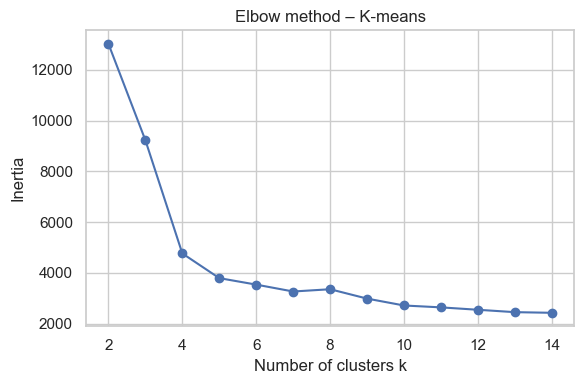

In [ ]:
inertias = []
k_range = range(2, min(len(df_samples), 15))
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow method – K-means")
plt.tight_layout()
plt.show()

## 7. Visualisation

### 7c. Dendrogram (hierarchical clustering)

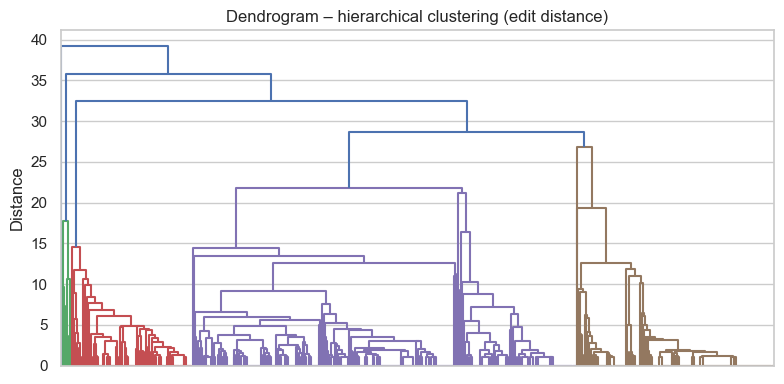

In [ ]:
condensed = squareform(dist_bp) 
Z = linkage(condensed, method="average")
df_samples["name"] = ["sample_" + str(i) for i in range(len(df_samples))]

plt.figure(figsize=(8, 4))
dendrogram(Z, labels=df_samples["name"].tolist(), leaf_rotation=45, no_labels=True)
plt.title("Dendrogram – hierarchical clustering (edit distance)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()